# Time Series Data Predictability

### Load required packages.

In [3]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import scipy.stats
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools 
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from dmba import regressionSummary
import warnings

import matplotlib.pylab as plt
%matplotlib inline

### Create data frame and time series data set for stock prices.

In [5]:
# Create data frame.
SP500_data = pd.read_csv('S&P500prices_19.csv')


# See the first and last 5 records of the file for S&P500 and Amtrak Ridership.
print('First and Last 5 Records of S&P500 Data')
print(SP500_data)
print('')

# Convert the date information to a datetime object as monthly data.
SP500_data['Date'] = pd.to_datetime(SP500_data.Date, format='%m/%d/%Y').dt.to_period('D')

# Convert data frame column to time series (name is used to label the data).
close_price_ts = pd.Series(SP500_data.ClosePrice.values, index=SP500_data.Date, name='ClosePrice')

# Define the time series frequency.
# close_price_ts.index = pd.DatetimeIndex(close_price_ts.index, freq=None)
# ridership_ts.index = pd.DatetimeIndex(ridership_ts.index, freq=ridership_ts.index.inferred_freq)

# Show/print first and last 5 records of S&P500 close price.
print('')
print('First and Last 5 Records of S&P500 Close Price')
print(close_price_ts)

First and Last 5 Records of S&P500 Data
           Date  OpenPrice     High      Low  ClosePrice  AdjClose
0      1/2/2019    2476.96  2519.49  2467.47     2510.03   2510.03
1      1/3/2019    2491.92  2493.14  2443.96     2447.89   2447.89
2      1/4/2019    2474.33  2538.07  2474.33     2531.94   2531.94
3      1/7/2019    2535.61  2566.16  2524.56     2549.69   2549.69
4      1/8/2019    2568.11  2579.82  2547.56     2574.41   2574.41
..          ...        ...      ...      ...         ...       ...
247  12/24/2019    3225.45  3226.43  3220.51     3223.38   3223.38
248  12/26/2019    3227.20  3240.08  3227.20     3239.91   3239.91
249  12/27/2019    3247.23  3247.93  3234.37     3240.02   3240.02
250  12/30/2019    3240.09  3240.92  3216.57     3221.29   3221.29
251  12/31/2019    3215.18  3231.72  3212.03     3230.78   3230.78

[252 rows x 6 columns]


First and Last 5 Records of S&P500 Close Price
Date
2019-01-02    2510.03
2019-01-03    2447.89
2019-01-04    2531.94
2019-01-07  

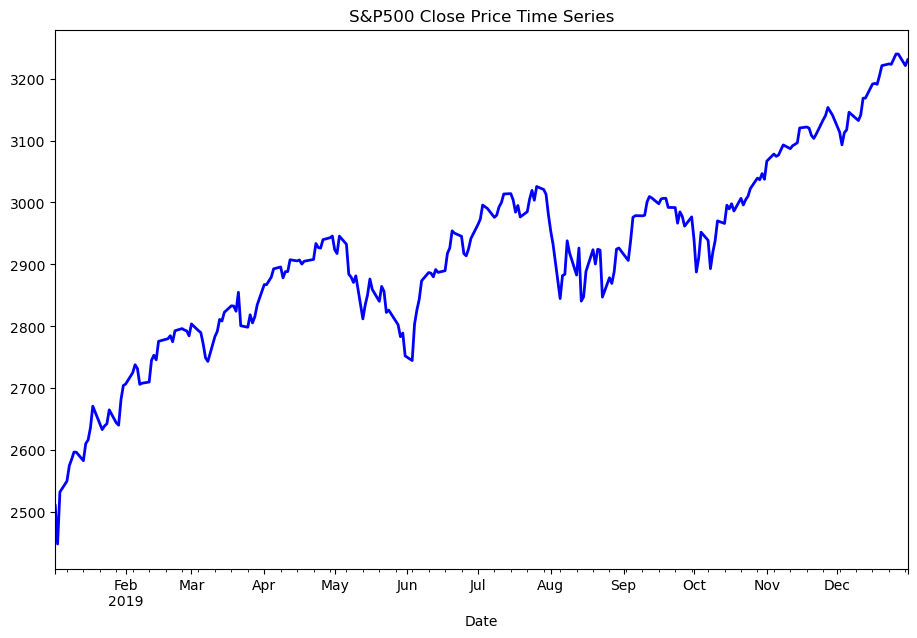

In [6]:
# Create plot for S&P500 close price. 
ax = close_price_ts.plot(color='blue', linewidth=2, figsize=(11,7))

# Create graph title.
# ax.legend(['S&P500 Close Price Time Series'])
plt.title('S&P500 Close Price Time Series')

plt.show()

### Test predictability of S&P500 close stock prices.

In [8]:
# Use ARIMA() function to fit AR(1) model for S&P500 close prices. 
# The Arima model of order=(1,0,0) gives an AR(1) model.
# Use summary() to identify parameters of AR(1) model. 
close_price_ar1 = ARIMA(close_price_ts, order=(1, 0, 0)).fit()

print(close_price_ar1.summary())


                               SARIMAX Results                                
Dep. Variable:             ClosePrice   No. Observations:                  252
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1144.553
Date:                Thu, 16 Jan 2025   AIC                           2295.106
Time:                        17:21:00   BIC                           2305.694
Sample:                    01-02-2019   HQIC                          2299.366
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2913.2855    347.547      8.382      0.000    2232.107    3594.464
ar.L1          0.9970      0.009    107.420      0.000       0.979       1.015
sigma2       505.6132     33.407     15.135      0.0

In [9]:
# Apply z-test to test the null hypothesis that beta 
# coefficient of AR(1) is equal to 1.
ar1 = 0.997
std_err = 0.009
null_mean = 1
alpha = 0.05
z_stat = round((ar1 - null_mean)/std_err, 5)
print('z_stat=',z_stat)
p_value = round(scipy.stats.norm.sf(abs(z_stat)), 5)
print('p_value=',p_value)
if p_value<alpha:
    print('Reject null hypothesis')
else:
    print('Accept null hypothesis')

z_stat= -0.33333
p_value= 0.36944
Accept null hypothesis


First and Last 5 First Differenced Close Price
Date
2019-01-02      NaN
2019-01-03   -62.14
2019-01-04    84.05
2019-01-07    17.75
2019-01-08    24.72
              ...  
2019-12-24    -0.63
2019-12-26    16.53
2019-12-27     0.11
2019-12-30   -18.73
2019-12-31     9.49
Freq: D, Name: ClosePrice, Length: 252, dtype: float64


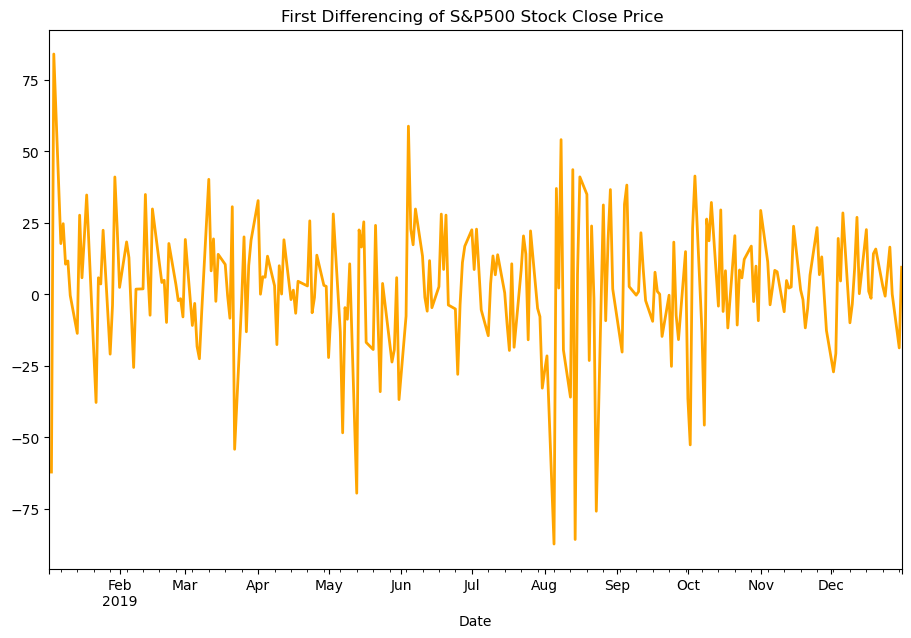

In [10]:
# Create differenced ClosePrice data using first differencing and print it.
diff_close_price = close_price_ts.diff(periods=1)

print('First and Last 5 First Differenced Close Price')
print(diff_close_price)

# Plot first differenced close price data. 
ax = diff_close_price.plot(color='orange',linewidth=2, figsize=(11,7))
plt.title('First Differencing of S&P500 Stock Close Price ')
plt.show()

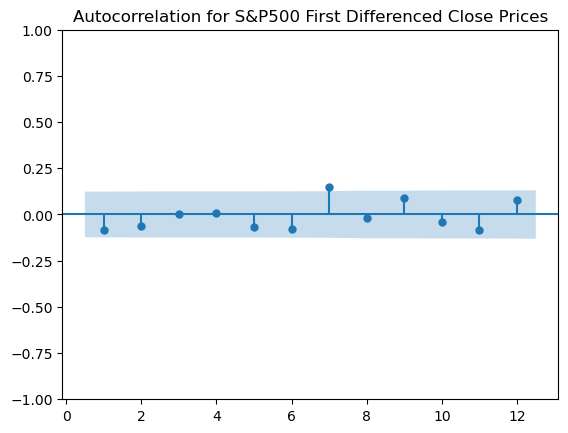

In [11]:
# Use plot_asf() function to identify autocorrelation for differenced
# ClosePrice and plot autocorrelation for different lags 
# (up to maximum of 12).

# Display autocorrrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. Starting with
# diff_close_price[1:] will exclude the undefined value (NaN) of the
# difference.
interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(diff_close_price[1:], lags=interval)

plt.title('Autocorrelation for S&P500 First Differenced Close Prices')
plt.show()


### Test predictability of Amtrak Ridership data.

In [13]:
# Create data frame.
Amtrak_data = pd.read_csv('Amtrak_comp.csv')

# Convert the date information to a datetime object as monthly data.
Amtrak_data['Date'] = pd.to_datetime(Amtrak_data.Month, format='%m/%d/%Y')

# Convert data frame column to time series (name is used to label the data).
ridership_ts = pd.Series(Amtrak_data.Ridership.values, index=Amtrak_data.Date, name='Ridership')

# Define the time series frequency.
ridership_ts.index = pd.DatetimeIndex(ridership_ts.index, freq=ridership_ts.index.inferred_freq)

# Show/print first and last 5 records of Amtrak Ridership Data.
print('')
print('First and Last 5 Records of Ridership Time Series')
print(ridership_ts)


First and Last 5 Records of Ridership Time Series
Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
                ...   
2018-08-01    2848.935
2018-09-01    2522.367
2018-10-01    2807.200
2018-11-01    2873.968
2018-12-01    2668.049
Freq: MS, Name: Ridership, Length: 336, dtype: float64


In [14]:
# Use ARIMA() function to fit AR(1) model for Amtrak Ridership. 
# The Arima model of order=(1,0,0) gives an AR(1) model.
# Use summary() to identify parameters of AR(1) model. 
ridership_ar1 = ARIMA(ridership_ts, order=(1, 0, 0)).fit()

print(ridership_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:              Ridership   No. Observations:                  336
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2233.346
Date:                Thu, 16 Jan 2025   AIC                           4472.691
Time:                        17:21:02   BIC                           4484.143
Sample:                    01-01-1991   HQIC                          4477.256
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2145.8585     84.453     25.409      0.000    1980.334    2311.383
ar.L1          0.8826      0.029     30.172      0.000       0.825       0.940
sigma2      3.457e+04   2368.905     14.593      0.0

In [15]:
# Apply z-test to test the null hypothesis that beta 
# coefficient of AR(1) is equal to 1.
ar_L1 = 0.8826
std_err = 0.029
null_mean = 1
alpha = 0.05
z_stat = round((ar_L1 - null_mean)/std_err, 5)
print('z_stat=',z_stat)
p_value = round(scipy.stats.norm.sf(abs(z_stat)), 5)
print('p_value=',p_value)
if p_value<alpha:
    print('Reject null hypothesis')
else:
    print('Accept null hypothesis')

z_stat= -4.04828
p_value= 3e-05
Reject null hypothesis


In [16]:
# Create differenced Amtrak Ridership data using first differencing.
diff_ridership_ts = ridership_ts.diff()

print(diff_ridership_ts)

Date
1991-01-01        NaN
1991-02-01    -88.331
1991-03-01    352.129
1991-04-01   -161.050
1991-05-01    163.299
               ...   
2018-08-01    -71.477
2018-09-01   -326.568
2018-10-01    284.833
2018-11-01     66.768
2018-12-01   -205.919
Freq: MS, Name: Ridership, Length: 336, dtype: float64


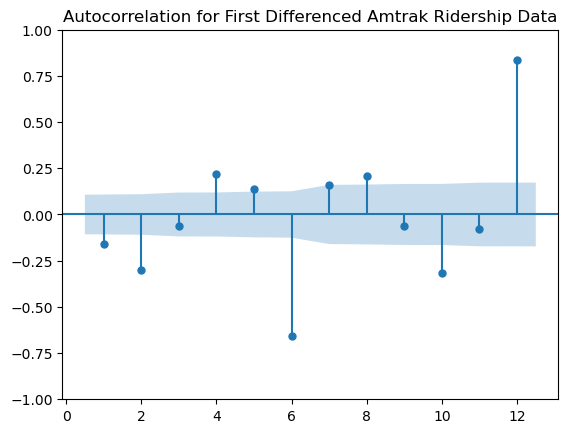

In [17]:
# Use plot_asf() function to identify autocorrelation for differenced
# ClosePrice and plot autocorrelation for different lags 
# (up to maximum of 12).

# Display autocorrelation chart. 
# Using specific lags [1, ..., 12] will exclude lag=0. Starting with
# diff_close_price[1:] will exclude the undefined value (NaN) of the
# difference.
tsaplots.plot_acf(diff_ridership_ts[1:], lags=interval)

plt.title('Autocorrelation for First Differenced Amtrak Ridership Data')
plt.show()